In [10]:
import sqlite3 as sql

file = '/data/CU_data/VR_Data/pp01/2026_06_14/omen-vr/FiveTower_Switch_BlackoutDelay_1.sqlite'
conn = sql.connect(file)



In [36]:
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
print(cursor.fetchall())

[('data',)]


In [12]:
cursor.execute("PRAGMA table_info(data)")
print(cursor.fetchall())

[(0, 'time', 'REAL', 0, None, 0), (1, 'trialnum', 'INT', 0, None, 0), (2, 'pos', 'REAL', 0, None, 0), (3, 'dz', 'REAL', 0, None, 0), (4, 'lick', 'INT', 0, None, 0), (5, 'reward', 'INT', 0, None, 0), (6, 'tstart', 'INT', 0, None, 0), (7, 'teleport', 'INT', 0, None, 0), (8, 'rzone', 'INT', 0, None, 0), (9, 'currrewardzone', 'TEXT', 0, None, 0), (10, 'currrewardcenter', 'REAL', 0, None, 0), (11, 'scanning', 'NUMERIC', 0, None, 0), (12, 'manrewards', 'INT', 0, None, 0), (13, 'autoreward', 'INT', 0, None, 0), (14, 'cmd', 'INT', 0, None, 0), (15, 'blackout', 'INT', 0, None, 0)]


In [13]:
import pandas as pd
df = pd.read_sql("SELECT * FROM data", conn)
print(df.memory_usage(deep=True).sum() / 1e6, 'MB')

downcast = df.copy()


# downcast integers
int_cols = downcast.select_dtypes(include='integer').columns
downcast[int_cols] = downcast[int_cols].apply(pd.to_numeric, downcast='integer')

# downcast floats
float_cols = downcast.select_dtypes(include='float').columns
downcast[float_cols] = downcast[float_cols].apply(pd.to_numeric, downcast='float')

print(downcast.memory_usage(deep=True).sum() / 1e6, 'MB')


27.22452 MB
13.000542 MB


In [16]:
downcast.columns

Index(['time', 'trialnum', 'pos', 'dz', 'lick', 'reward', 'tstart', 'teleport',
       'rzone', 'currrewardzone', 'currrewardcenter', 'scanning', 'manrewards',
       'autoreward', 'cmd', 'blackout'],
      dtype='object')

In [20]:
downcast.currrewardcenter

0         300.0
1         300.0
2         300.0
3         300.0
4         300.0
          ...  
152941    400.0
152942    400.0
152943    400.0
152944    400.0
152945    400.0
Name: currrewardcenter, Length: 152946, dtype: float32

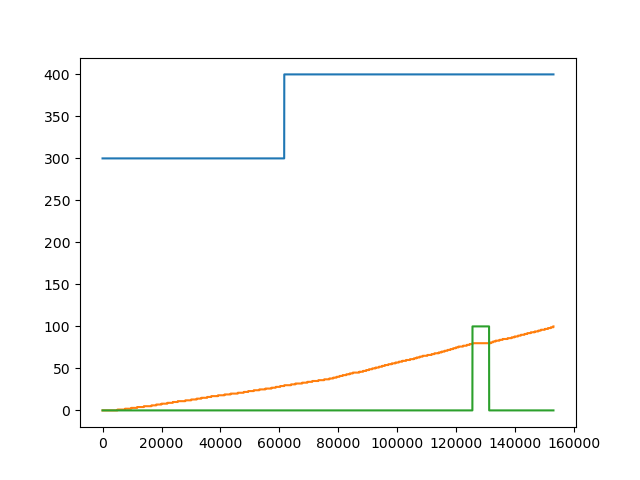

In [35]:
%matplotlib widget
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
plt.plot(downcast.currrewardcenter)
plt.plot(downcast.trialnum)
plt.plot((downcast.blackout>0)*100)

In [24]:
trial_df = downcast.drop_duplicates('trialnum')

In [34]:
trial_df.blackout.max()

1

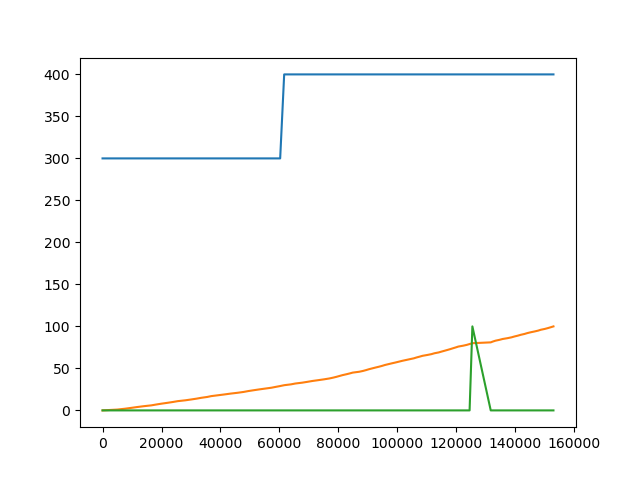

In [33]:
fig, ax = plt.subplots()
plt.plot(trial_df.currrewardcenter)
plt.plot(trial_df.trialnum)
plt.plot((trial_df.blackout>0)*100)

In [38]:
downcast.loc[downcast.rzone >0]

,time,trialnum,pos,dz,lick,reward,tstart,teleport,rzone,currrewardzone,currrewardcenter,scanning,manrewards,autoreward,cmd,blackout
3686,54.716660,0,275.313721,0.3576,0,0,1,0,1,C,300.0,0,0,0,0,0
3687,54.733192,0,275.671326,0.3576,0,0,1,0,1,C,300.0,0,0,0,0,0
3688,54.749413,0,276.207733,0.5364,0,0,1,0,1,C,300.0,0,0,0,0,0
3689,54.758369,0,276.788818,0.5811,0,0,1,0,1,C,300.0,0,0,0,0,0
3690,54.767883,0,277.057007,0.2682,0,0,1,0,1,C,300.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150643,2584.398682,97,375.588654,0.2682,1,0,1,1,1,D,400.0,0,0,0,4,0
151652,2605.415283,98,374.694763,0.1788,0,0,1,1,1,D,400.0,0,0,0,0,0
151653,2605.437256,98,374.918274,0.2235,0,0,1,1,1,D,400.0,0,0,0,0,0
151654,2605.460449,98,375.141785,0.2235,1,0,1,1,1,D,400.0,0,0,0,0,0


In [27]:
trial_df

,time,trialnum,pos,dz,lick,reward,tstart,teleport,rzone,currrewardzone,currrewardcenter,scanning,manrewards,autoreward,cmd,blackout
0,2.550122,0,-5.0,0.0000,0,0,0,0,0,C,300.0,0,0,0,2,0
5043,73.439095,1,-50.0,0.3576,0,0,1,1,0,C,300.0,0,0,0,0,0
7595,109.213211,2,-50.0,0.4023,0,0,1,1,0,C,300.0,0,0,0,0,0
9717,138.890335,3,-50.0,0.7152,0,0,1,1,0,C,300.0,0,0,0,0,0
11732,166.843323,4,-50.0,0.6258,0,0,1,1,0,C,300.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148652,2542.580811,96,-50.0,0.4917,0,0,1,1,0,D,400.0,0,0,0,0,0
150017,2571.030518,97,-50.0,0.6258,0,0,1,1,0,D,400.0,0,0,0,0,0
151072,2593.149170,98,-50.0,0.8940,0,0,1,1,0,D,400.0,0,0,0,0,0
152030,2612.903564,99,-50.0,0.5811,0,0,1,1,0,D,400.0,0,0,0,0,0


In [61]:
import os
import numpy as np
def load_sqlite(fpath, downcast = True):
    conn = sql.connect(fpath)
    df = pd.read_sql("SELECT * FROM data", conn)
    conn.close()
    if downcast:

        


        # downcast integers
        int_cols = df.select_dtypes(include='integer').columns
        df[int_cols] = df[int_cols].apply(pd.to_numeric, downcast='integer')

        # downcast floats
        float_cols = df.select_dtypes(include='float').columns
        df[float_cols] = df[float_cols].apply(pd.to_numeric, downcast='float')
    
    return df

def get_sqlite_fpath(sess):
    return os.path.join(sess['basedir_VR'], sess['vr_filename'])


def get_reward_zones_from_sqlite_file(fpath, 
                                 reward_zone_center_col = 'currrewardcenter', 
                                 reward_zone_width = 50):
    ''' Get reward zone positions and labels for a given session based on sqlite file.
    :param sess: session class

    :return: rz_coords: 2 x N array of zone [start, stop] positions by N trials
             rz_labels: 1 x N array of task-relevant zone label (i.e. 'A') by N trials'''
    
    
    df = load_sqlite(fpath)

    trials = df.drop_duplicates('trialnum')
    rzone_centers = trials[reward_zone_center_col].values
    
    rz_coords = np.repeat(rzone_centers[:,np.newaxis],2, axis = 1)

    rz_coords[:,0] = rz_coords[:,0] - reward_zone_width / 2
    rz_coords[:,1] = rz_coords[:,1] + reward_zone_width / 2


    rz_labels = trials['currrewardzone']
    
    return rz_coords, rz_labels.values

In [62]:
coords, labels = get_reward_zones_from_sqlite_file(file)